# using regression for a classification problem

In [1]:
# import a binary classificaiton dataset from sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X = data.data
y = data.target

# create pandas dataframe from X and y
import pandas as pd

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()


std.fit(df.drop('target', axis=1))

StandardScaler()

In [3]:
std.mean_.shape

(30,)

In [4]:
std.var_.shape

(30,)

In [5]:
dir(std)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_reset',
 '_sklearn_auto_wrap_output_keys',
 '_validate_data',
 '_validate_params',
 'copy',
 'feature_names_in_',
 'fit',
 'fit_transform',
 'get_feature_names_out',


In [6]:
df['target'].value_counts()

,count
target,
1,357
0,212


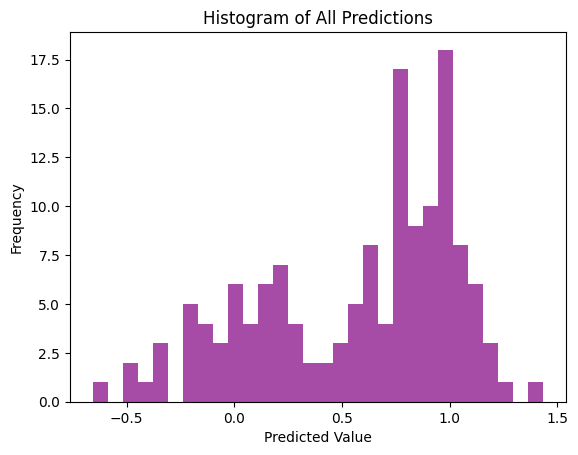

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

from matplotlib import pyplot as plt


plt.hist(pred, bins=30, alpha=0.7, color='purple')
plt.xlabel('Predicted Value')
plt.ylabel('Frequency')
plt.title('Histogram of All Predictions')
plt.show()

In [8]:
import math


def sigmoid(x):
  return 1/(1 + math.exp(-x))


sigmoid(-100)

3.7200759760208356e-44

In [9]:
math.exp(-1000000000)

0.0

In [10]:
import math

def log_loss(y_true, y_pred):
  """
  Calculates the binary log-loss (cross-entropy loss).

  Args:
    y_true: The true label (0 or 1).
    y_pred: The predicted probability that the label is 1.

  Returns:
    The log-loss value.
  """
  # Ensure y_pred is within a small epsilon to avoid math.log(0)
  epsilon = 1e-15
  y_pred = max(epsilon, min(1 - epsilon, y_pred))

  return -(y_true * math.log(y_pred) + (1 - y_true) * math.log(1 - y_pred))

Here are some examples of how to use the `log_loss` function:

In [11]:
# Example usage:
print(f"Log loss for (true=1, pred=0.9): {log_loss(1, 0.9):.4f}")
print(f"Log loss for (true=1, pred=0.1): {log_loss(1, 0.1):.4f}")
print(f"Log loss for (true=0, pred=0.9): {log_loss(0, 0.9):.4f}")
print(f"Log loss for (true=0, pred=0.1): {log_loss(0, 0.1):.4f}")
print(f"Log loss for (true=0, pred=0.5): {log_loss(0, 0.5):.4f}")

Log loss for (true=1, pred=0.9): 0.1054
Log loss for (true=1, pred=0.1): 2.3026
Log loss for (true=0, pred=0.9): 2.3026
Log loss for (true=0, pred=0.1): 0.1054
Log loss for (true=0, pred=0.5): 0.6931


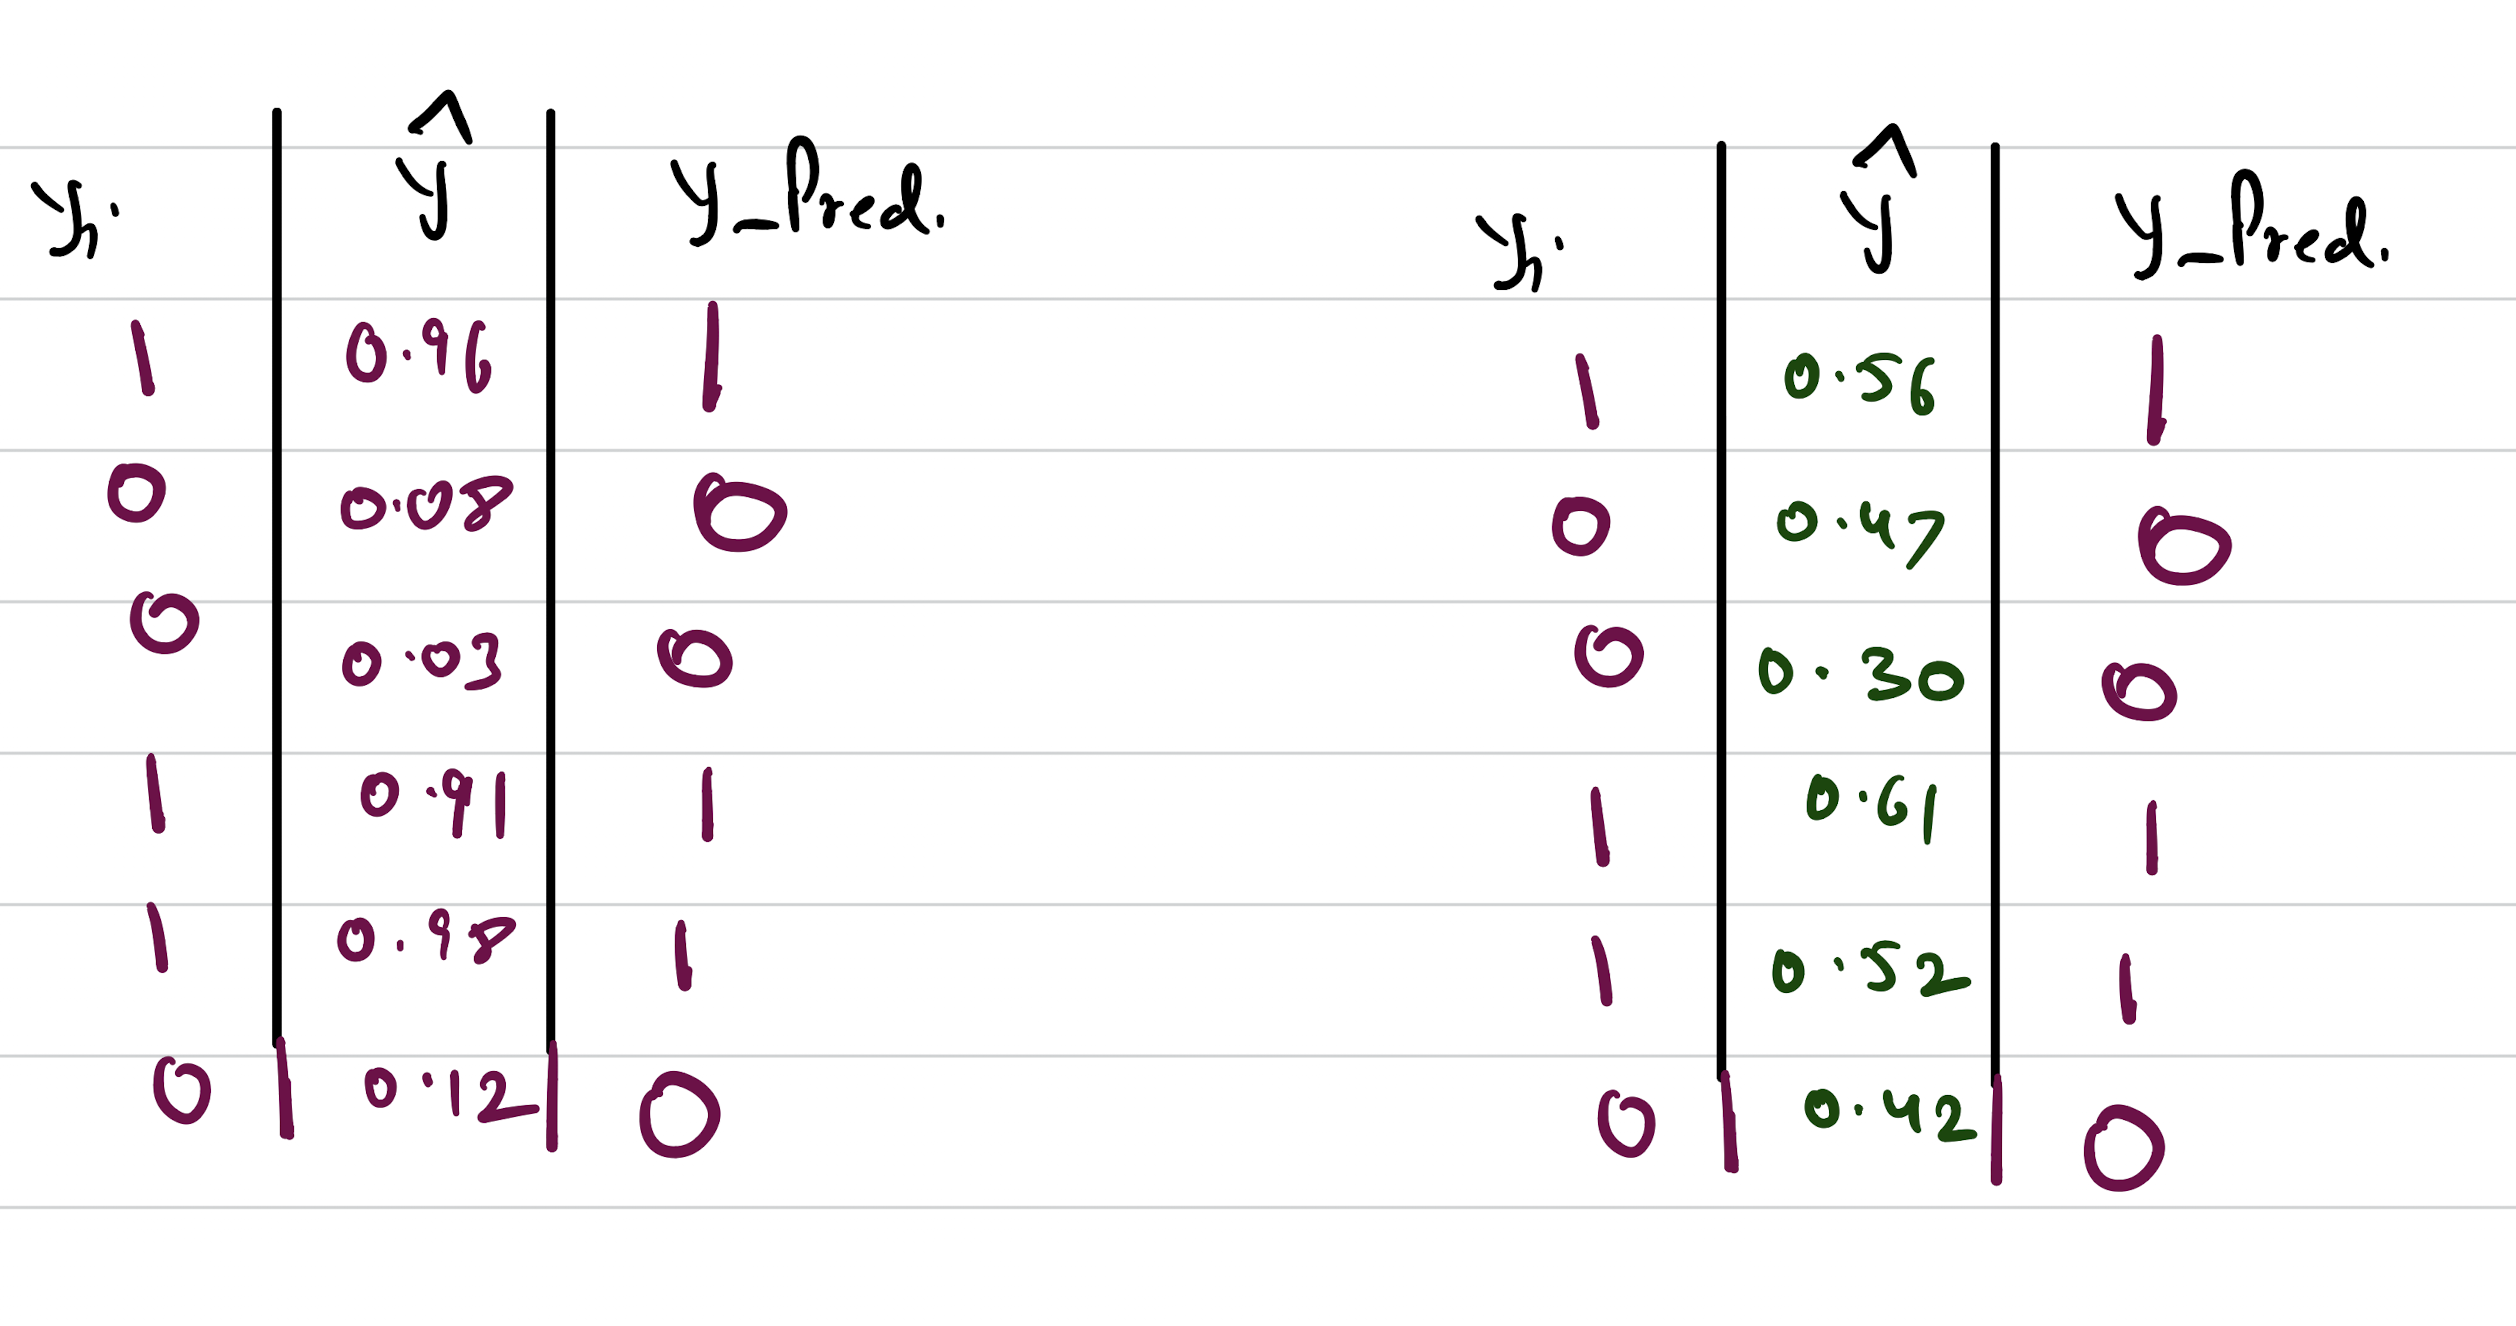

In [12]:
log_loss(1, 0.9)

0.10536051565782628

In [13]:
log_loss(1, 0.1)

2.3025850929940455

In [14]:
#bad model
log_loss(1, 0.56) + log_loss(0, 0.47) + log_loss(0, 0.30) + log_loss(1, 0.61) + log_loss(1, 0.52) + log_loss(0, 0.42)

3.2643216762907596

In [15]:
# good model
log_loss(1, 0.96) + log_loss(0, 0.08) + log_loss(0, 0.03) + log_loss(1, 0.91) + log_loss(1, 0.98) + log_loss(0, 0.12)

0.39700956924266034

In [ ]:
math.log(0.01)